In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import datetime
from datetime import datetime
from geopy import geocoders  

In [93]:
weather=pd.read_csv("weather.csv",encoding='utf-8')
cab_rides=pd.read_csv("cab_rides.csv",encoding='utf-8')
cab_rides


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL
...,...,...,...,...,...,...,...,...,...,...
693066,1.00,Uber,1543708385534,North End,West End,13.0,1.0,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
693067,1.00,Uber,1543708385534,North End,West End,9.5,1.0,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
693068,1.00,Uber,1543708385534,North End,West End,NaN,1.0,64d451d0-639f-47a4-9b7c-6fd92fbd264f,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
693069,1.00,Uber,1543708385534,North End,West End,27.0,1.0,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV


In [94]:
cab_rides.drop_duplicates(inplace=True)
cab_rides.dropna(inplace=True)
cab_rides['time_stamp'] = pd.to_datetime(
    cab_rides['time_stamp'], unit='ms').dt.floor('h')
cab_rides

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,2018-12-16 09:00:00,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,2018-11-27 02:00:00,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,2018-11-28 01:00:00,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,2018-11-30 04:00:00,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,2018-11-29 03:00:00,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL
...,...,...,...,...,...,...,...,...,...,...
693065,1.00,Uber,2018-12-01 23:00:00,North End,West End,9.5,1.0,353e6566-b272-479e-a9c6-98bd6cb23f25,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV
693066,1.00,Uber,2018-12-01 23:00:00,North End,West End,13.0,1.0,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
693067,1.00,Uber,2018-12-01 23:00:00,North End,West End,9.5,1.0,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
693069,1.00,Uber,2018-12-01 23:00:00,North End,West End,27.0,1.0,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV


In [95]:
weather.head()

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


In [96]:
weather.drop_duplicates(inplace=True)
weather.fillna(0, inplace=True)
weather['time_stamp'] = pd.to_datetime(
    weather['time_stamp'],unit='s').dt.floor('h')
# weather.sort_values(by=['time_stamp'])
weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.00,1012.14,0.1228,2018-12-16 23:00:00,0.77,11.25
1,42.43,Beacon Hill,1.00,1012.15,0.1846,2018-12-16 23:00:00,0.76,11.32
2,42.50,Boston University,1.00,1012.15,0.1089,2018-12-16 23:00:00,0.76,11.07
3,42.11,Fenway,1.00,1012.13,0.0969,2018-12-16 23:00:00,0.77,11.09
4,43.13,Financial District,1.00,1012.14,0.1786,2018-12-16 23:00:00,0.75,11.49
...,...,...,...,...,...,...,...,...
6271,44.72,North Station,0.89,1000.69,0.0000,2018-12-03 06:00:00,0.96,1.52
6272,44.85,Northeastern University,0.88,1000.71,0.0000,2018-12-03 06:00:00,0.96,1.54
6273,44.82,South Station,0.89,1000.70,0.0000,2018-12-03 06:00:00,0.96,1.54
6274,44.78,Theatre District,0.89,1000.70,0.0000,2018-12-03 06:00:00,0.96,1.54


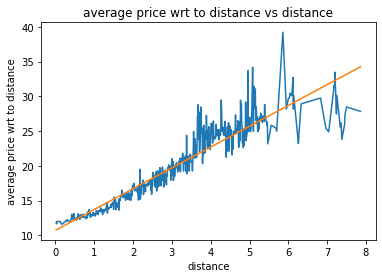

In [97]:
dist_price = cab_rides[['distance', 'price']]
dist_price=dist_price.groupby("distance")
plt.title('average price wrt to distance vs distance')
plt.xlabel('distance')
plt.ylabel('average price wrt to distance')
plt.plot(dist_price.groups.keys(), dist_price['price'].mean())
x_distance=np.array(list(dist_price.groups.keys())).reshape(-1, 1)
y_price=dist_price['price'].mean()
model = LinearRegression().fit(x_distance, y_price)
price=x_distance*model.coef_+model.intercept_
plt.plot(x_distance,price)
plt.show()

In [98]:
model.intercept_

10.730239641932323

In [99]:
model.coef_

array([2.9923623])

In [197]:
print("总体而言，网约车的距离和价格是成正比的，每一mile的价格大概在10.73美元左右。并且当距离短的时候，价格波动比较小，距离越长，价格波动越大。")

总体而言，网约车的距离和价格是成正比的，每一mile的价格大概在10.73美元左右。并且当距离短的时候，价格波动比较小，距离越长，价格波动越大。


In [100]:
#unit_price=cab_rides["price"]/cab_rides["distance"]
#unit_price.mean()

In [101]:
#plt.scatter(x_distance,y_price)
#plt.plot(x_distance,price,'r')
#plt.legend(["Actual","Predict"])

In [102]:
weather=weather.fillna(0)
weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.00,1012.14,0.1228,2018-12-16 23:00:00,0.77,11.25
1,42.43,Beacon Hill,1.00,1012.15,0.1846,2018-12-16 23:00:00,0.76,11.32
2,42.50,Boston University,1.00,1012.15,0.1089,2018-12-16 23:00:00,0.76,11.07
3,42.11,Fenway,1.00,1012.13,0.0969,2018-12-16 23:00:00,0.77,11.09
4,43.13,Financial District,1.00,1012.14,0.1786,2018-12-16 23:00:00,0.75,11.49
...,...,...,...,...,...,...,...,...
6271,44.72,North Station,0.89,1000.69,0.0000,2018-12-03 06:00:00,0.96,1.52
6272,44.85,Northeastern University,0.88,1000.71,0.0000,2018-12-03 06:00:00,0.96,1.54
6273,44.82,South Station,0.89,1000.70,0.0000,2018-12-03 06:00:00,0.96,1.54
6274,44.78,Theatre District,0.89,1000.70,0.0000,2018-12-03 06:00:00,0.96,1.54


In [103]:
weather['time_stamp'] = pd.to_datetime(weather['time_stamp'], unit='s').dt.floor('h')
weather.sort_values(by=['time_stamp'])

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
4001,40.95,Financial District,0.89,1014.35,0.0,2018-11-26 03:00:00,0.93,1.49
4003,40.80,Theatre District,0.87,1014.39,0.0,2018-11-26 03:00:00,0.93,1.55
4002,40.94,North Station,0.89,1014.35,0.0,2018-11-26 03:00:00,0.92,1.43
2661,40.84,Fenway,0.88,1014.35,0.0,2018-11-26 03:00:00,0.93,1.31
4000,41.07,Boston University,0.86,1014.39,0.0,2018-11-26 03:00:00,0.92,1.36
...,...,...,...,...,...,...,...,...
3194,30.85,North End,0.00,1012.31,0.0,2018-12-18 18:00:00,0.46,13.14
3195,30.91,Northeastern University,0.00,1012.34,0.0,2018-12-18 18:00:00,0.46,13.06
3196,31.20,South Station,0.00,1012.31,0.0,2018-12-18 18:00:00,0.45,13.19
3197,30.81,Theatre District,0.00,1012.32,0.0,2018-12-18 18:00:00,0.46,13.15


In [104]:
cab_rides['time_stamp'] = pd.to_datetime(cab_rides['time_stamp'], unit='ms').dt.floor('h')
cab_rides.sort_values(by=['time_stamp'])

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
261361,2.30,Lyft,2018-11-26 03:00:00,Boston University,Beacon Hill,9.0,1.00,d3d168df-a1b6-4de3-b1a1-7d1fb464bd41,lyft,Lyft
397656,3.26,Lyft,2018-11-26 03:00:00,Fenway,Theatre District,7.0,1.00,31a115fc-c718-4b98-9fbc-8a0c381ea764,lyft_line,Shared
397655,3.39,Uber,2018-11-26 03:00:00,North Station,Boston University,18.0,1.00,e4207a18-7ace-4edb-8bd3-7dea8b6ee004,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
397654,3.39,Uber,2018-11-26 03:00:00,North Station,Boston University,10.0,1.00,ba860bcc-eef4-4ed9-98a8-064ebc31d414,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool
546625,4.46,Lyft,2018-11-26 03:00:00,Financial District,Boston University,62.5,1.75,1178f52c-9bd4-4b28-a03a-d94e68bfafa3,lyft_lux,Lux Black
...,...,...,...,...,...,...,...,...,...,...
517605,3.22,Uber,2018-12-18 19:00:00,North Station,Northeastern University,9.5,1.00,4e9e347d-2652-4814-b477-19edc8a6a1d1,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
517604,3.44,Uber,2018-12-18 19:00:00,Back Bay,South Station,10.5,1.00,5f73708a-3518-43d9-af1e-97e8b893fc39,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
175534,1.72,Uber,2018-12-18 19:00:00,South Station,West End,8.0,1.00,a8f366f4-5133-4a0d-9ca8-b643e6ee1484,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool
133216,1.41,Uber,2018-12-18 19:00:00,Theatre District,North End,16.0,1.00,9eb5dc76-47c5-40b7-89fe-5ba166a96f4a,6c84fd89-3f11-4782-9b50-97c468b19529,Black


In [105]:
cab_drives_weather = cab_rides.merge(right=weather, left_on=['time_stamp', 'source'], right_on=['time_stamp', 'location'])
cab_drives_weather

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,location,clouds,pressure,rain,humidity,wind
0,0.44,Lyft,2018-12-16 09:00:00,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
1,1.33,Lyft,2018-12-16 09:00:00,Beacon Hill,Haymarket Square,7.0,1.0,0d468502-34b5-447f-be9f-acbb62176072,lyft,Lyft,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
2,0.53,Lyft,2018-12-16 09:00:00,North Station,Haymarket Square,27.5,1.0,2aa8d17e-4b13-4200-87db-db3eed73ca6b,lyft_luxsuv,Lux Black XL,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
3,2.36,Lyft,2018-12-16 09:00:00,Back Bay,Haymarket Square,7.0,1.0,4944c164-0463-47b9-96e1-15ffe8b9c7c9,lyft_line,Shared,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
4,0.62,Uber,2018-12-16 09:00:00,West End,Haymarket Square,10.5,1.0,b1c23003-39fb-4030-9961-4f3420b23907,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1164991,1.50,Uber,2018-11-28 08:00:00,Back Bay,Fenway,13.0,1.0,d183c066-baeb-449c-9027-d810a2ba22b1,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,34.86,Fenway,0.55,991.77,0.0,0.79,5.70
1164992,1.50,Uber,2018-11-28 08:00:00,Back Bay,Fenway,13.0,1.0,d183c066-baeb-449c-9027-d810a2ba22b1,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,34.53,Fenway,0.47,991.94,0.0,0.81,6.13
1164993,1.50,Uber,2018-11-28 08:00:00,Back Bay,Fenway,13.0,1.0,d183c066-baeb-449c-9027-d810a2ba22b1,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,34.84,Fenway,0.55,991.77,0.0,0.79,5.72
1164994,1.50,Uber,2018-11-28 08:00:00,Back Bay,Fenway,13.0,1.0,d183c066-baeb-449c-9027-d810a2ba22b1,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,34.74,Fenway,0.52,991.83,0.0,0.80,5.86


In [108]:
#x_temp=cab_drives_weather["temp"].values.reshape(-1,1)
#y_price=cab_drives_weather["price"].values.reshape(-1,1)
#model_temp = LinearRegression().fit(x_temp, y_price)

#price_temp= model_temp.coef_ * x_temp + model_temp.intercept_
#model_temp.coef_

In [109]:
#plt.scatter(x_temp,y_price)
#plt.plot(x_temp,price_temp,'r')
#plt.legend(["Actual","Predict"])

In [110]:
#x_clouds=cab_drives_weather["clouds"].values.reshape(-1,1)
#model_clouds = LinearRegression().fit(x_clouds, y_price)
#price_clouds= model_clouds.coef_ * x_clouds + model_clouds.intercept_
#model_clouds.coef_

In [111]:
#plt.scatter(x_clouds,y_price)
#plt.plot(x_clouds,price_clouds,'r')
#plt.legend(["Actual","Predict"])

In [112]:
#x_rain=cab_drives_weather["rain"].values.reshape(-1,1)
#model_rain = LinearRegression().fit(x_rain, y_price)
#price_rain= model_rain.coef_ * x_rain + model_rain.intercept_
#model_rain.coef_

In [113]:
#plt.scatter(x_rain,y_price)
#plt.plot(x_rain,price_rain,'r')
#plt.legend(["Actual","Predict"])

In [114]:
#x_wind=cab_drives_weather["wind"].values.reshape(-1,1)
#model_wind = LinearRegression().fit(x_wind, y_price)
#price_wind= model_wind.coef_ * x_wind + model_wind.intercept_
#model_wind.coef_

In [115]:
#plt.scatter(x_wind,y_price)
#plt.plot(x_wind,price_wind,'r')
#plt.legend(["Actual","Predict"])

In [116]:
#x_humidity=cab_drives_weather["humidity"].values.reshape(-1,1)
#model_humidity = LinearRegression().fit(x_humidity, y_price)
#price_humidity= model_humidity.coef_ * x_humidity + model_humidity.intercept_
#model_humidity.coef_ 

In [117]:
#plt.scatter(x_humidity,y_price)
#plt.plot(x_humidity,price_humidity,'r')
#plt.legend(["Actual","Predict"])

In [118]:
drives_type=cab_drives_weather.groupby("name")
drives_type.first()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,temp,location,clouds,pressure,rain,humidity,wind
name,,,,,,,,,,,,,,,,
Black,0.91,Uber,2018-12-16 09:00:00,Beacon Hill,Haymarket Square,15.0,1.0,f49d2bce-4c0f-4160-b10e-b7086a23b1f0,6c84fd89-3f11-4782-9b50-97c468b19529,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
Black SUV,0.49,Uber,2018-12-16 09:00:00,North Station,Haymarket Square,26.0,1.0,b2c44c57-4728-441e-83ce-f796a55e6b20,6d318bcc-22a3-4af6-bddd-b409bfce1546,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
Lux,2.38,Lyft,2018-12-16 09:00:00,Back Bay,Haymarket Square,16.5,1.0,e20be752-be44-4093-8600-c48608b7079e,lyft_premier,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
Lux Black,1.96,Lyft,2018-12-16 09:00:00,Back Bay,Haymarket Square,22.5,1.0,10a5fdd6-4baa-4dc5-8ad8-8976080a361b,lyft_lux,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
Lux Black XL,0.53,Lyft,2018-12-16 09:00:00,North Station,Haymarket Square,27.5,1.0,2aa8d17e-4b13-4200-87db-db3eed73ca6b,lyft_luxsuv,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
Lyft,1.33,Lyft,2018-12-16 09:00:00,Beacon Hill,Haymarket Square,7.0,1.0,0d468502-34b5-447f-be9f-acbb62176072,lyft,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
Lyft XL,1.04,Lyft,2018-12-16 09:00:00,Financial District,Haymarket Square,10.5,1.0,80027d68-76ff-4948-815d-d84f3ad3120c,lyft_plus,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
Shared,0.44,Lyft,2018-12-16 09:00:00,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68
UberPool,0.61,Uber,2018-12-16 09:00:00,West End,Haymarket Square,6.5,1.0,04f35170-0dad-4ae2-b5c9-02310e811fd8,997acbb5-e102-41e1-b155-9df7de0a73f2,38.46,Haymarket Square,0.29,1022.25,0.0,0.76,7.68


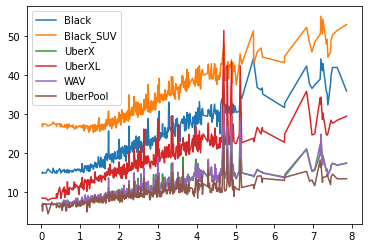

In [119]:
Black=drives_type.get_group('Black')
Black = Black.groupby('distance')['price']
plt.plot(Black.groups.keys(), Black.mean(), label='Black')

Black_SUV=drives_type.get_group('Black SUV')
Black_SUV = Black_SUV.groupby('distance')['price']
plt.plot(Black_SUV.groups.keys(), Black_SUV.mean(), label='Black_SUV')

UberX=drives_type.get_group('UberX')
UberX= UberX.groupby('distance')['price']
plt.plot(UberX.groups.keys(), UberX.mean(), label='UberX')

UberXL=drives_type.get_group('UberXL')
UberXL= UberXL.groupby('distance')['price']
plt.plot(UberXL.groups.keys(), UberXL.mean(), label='UberXL')

WAV=drives_type.get_group('WAV')
WAV= WAV.groupby('distance')['price']
plt.plot(WAV.groups.keys(), WAV.mean(), label='WAV')

UberPool=drives_type.get_group('UberPool')
UberPool =UberPool.groupby('distance')['price']
plt.plot(UberPool.groups.keys(), UberPool.mean(), label='UberPool')

plt.legend()
plt.show()

In [120]:
print("我们可以从Uber的所有产品中看出，uberpool是最便宜，black SUV是最贵的。根据提供的服务和车型的不同，价格也区别较大。在距离较短的时候价格趋于稳定，在距离较长的时候价格变化较大。")

我们可以从Uber的所有产品中看出，uberpool是最便宜，black SUV是最贵的。根据提供的服务和车型的不同，价格也区别较大。WAV和UberX的价格是差不多。在距离较短的时候价格趋于稳定，在距离较长的时候价格变化较大。


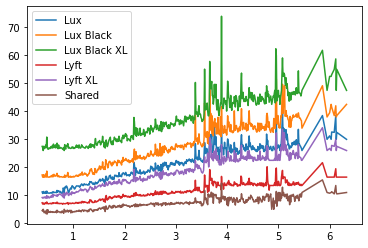

In [178]:
Lux=drives_type.get_group('Lux')
Lux= Lux.groupby('distance')['price']
plt.plot(Lux.groups.keys(), Lux.mean(), label='Lux')

Lux_Black=drives_type.get_group('Lux Black')
Lux_Black= Lux_Black.groupby('distance')['price']
plt.plot(Lux_Black.groups.keys(), Lux_Black.mean(), label='Lux Black')

Lux_Black_XL=drives_type.get_group('Lux Black XL')
Lux_Black_XL= Lux_Black_XL.groupby('distance')['price']
plt.plot(Lux_Black_XL.groups.keys(), Lux_Black_XL.mean(), label='Lux Black XL')

Lyft=drives_type.get_group('Lyft')
Lyft= Lyft.groupby('distance')['price']
plt.plot(Lyft.groups.keys(),Lyft.mean(), label='Lyft')

Lyft_XL=drives_type.get_group('Lyft XL')
Lyft_XL= Lyft_XL.groupby('distance')['price']
plt.plot(Lyft_XL.groups.keys(), Lyft_XL.mean(), label='Lyft XL')

Shared=drives_type.get_group('Shared')
Shared = Shared.groupby('distance')['price']
plt.plot(Shared.groups.keys(), Shared.mean(), label='Shared')

plt.legend()
plt.show()

In [176]:
print("Lyft里面也是根据车型和服务的不同价格有差异。Shared是所有车型里面价格最便宜的，Lux Black XL是里面最贵的。并且lyft开始价格较大起伏的距离比Uber会较短一些。")

Lyft里面也是根据车型和服务的不同价格有差异。Shared是所有车型里面价格最便宜的，Lux Black XL是里面最贵的。并且lyft开始价格较大起伏的距离比Uber会较短一些。


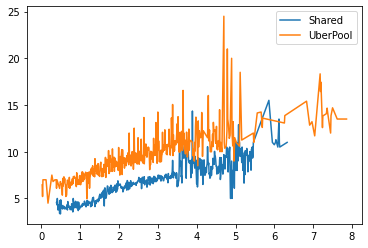

In [179]:
plt.plot(Shared.groups.keys(), Shared.mean(), label='Shared')
plt.plot(UberPool.groups.keys(), UberPool.mean(), label='UberPool')
plt.legend()
plt.show()

In [177]:
print("对于最便宜的车型，uber的价格还是略高于Lyft的。")

对于最便宜的车型，uber的价格还是略高于Lyft的。


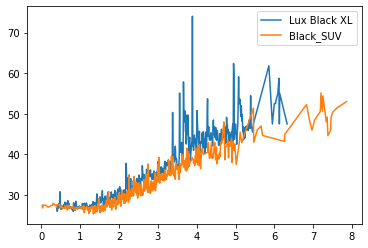

In [180]:
plt.plot(Lux_Black_XL.groups.keys(), Lux_Black_XL.mean(), label='Lux Black XL')
plt.plot(Black_SUV.groups.keys(), Black_SUV.mean(), label='Black_SUV')
plt.legend()
plt.show()

In [181]:
print("对于最贵的车型uber比lyft价格要便宜,并且lyft的价格波动更大。")

对于最贵的车型uber比lyft价格要便宜。


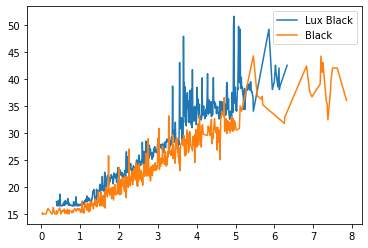

In [182]:
plt.plot(Lux_Black.groups.keys(), Lux_Black.mean(), label='Lux Black')
plt.plot(Black.groups.keys(), Black.mean(), label='Black')
plt.legend()
plt.show()

In [183]:
print("第二贵的车型uber还是比lyft总体要合算，并且对于lyft在更短的距离开始比较大的价格波动。")

第二贵的车型uber还是比lyft总体要合算，并且对于lyft在更短的距离开始比较大的价格波动。


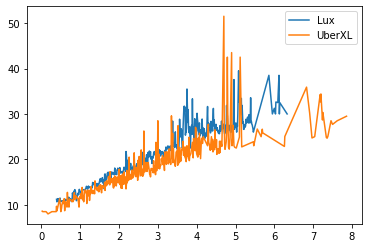

In [191]:
plt.plot(Lux.groups.keys(), Lux.mean(), label='Lux')
plt.plot(UberXL.groups.keys(), UberXL.mean(), label='UberXL')
plt.legend()
plt.show()

In [192]:
print("第三贵的车型里面总体uber的价格相当还是比较便宜，但是这次uber的价格变动更大。")

第三贵的车型里面总体uber的价格相当还是比较便宜，但是这次uber的价格变动更大。


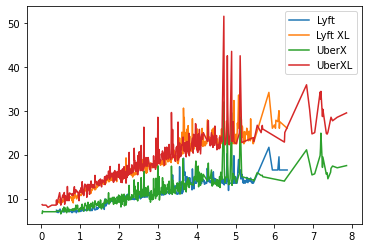

In [193]:
plt.plot(Lyft.groups.keys(),Lyft.mean(), label='Lyft')
plt.plot(Lyft_XL.groups.keys(), Lyft_XL.mean(), label='Lyft XL')
plt.plot(UberX.groups.keys(), UberX.mean(), label='UberX')
plt.plot(UberXL.groups.keys(), UberXL.mean(), label='UberXL')

plt.legend()
plt.show()

In [194]:
print("UberX和Lyft的价格是差不多的；UberXL和lyft XL价格相差不大，但是Uber的价格总体波动更大。")

UberX和Lyft的价格是差不多的；UberXL和lyft XL价格相差不大，但是Uber的价格总体波动更大。


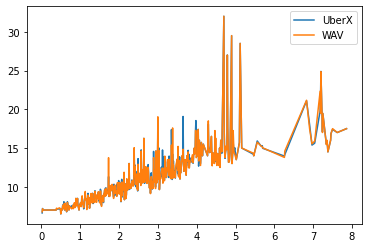

In [195]:
plt.plot(UberX.groups.keys(), UberX.mean(), label='UberX')
plt.plot(WAV.groups.keys(), WAV.mean(), label='WAV')
plt.legend()
plt.show()

In [196]:
print("Uber里面Uber X和WAV的价格基本一致，并且长距离价格波动较大。")

Uber里面Uber X和WAV的价格基本一致，并且长距离价格波动较大。


In [124]:
#black=drives_type.get_group('Black')
#unit_price_black=black["price"]/black["distance"]
#unit_price_black.mean()

In [125]:
#model_black = LinearRegression().fit(black['distance'].values.reshape(-1,1),black['price'].values.reshape(-1,1))
#model_black.coef_ 

In [126]:
#model_black.intercept_

In [127]:
#black

In [128]:
#Black_SUV=drives_type.get_group('Black SUV')
#unit_price_Black_SUV=Black_SUV["price"]/Black_SUV["distance"]
#unit_price_Black_SUV.mean()

In [129]:
#model_Black_SUV = LinearRegression().fit(Black_SUV['distance'].values.reshape(-1,1),Black_SUV['price'].values.reshape(-1,1))
#model_Black_SUV.coef_ 


In [130]:
#model_Black_SUV.intercept_ 

In [131]:
#Black_SUV

In [132]:
#Lux=drives_type.get_group('Lux')
#unit_price_Lux=Lux["price"]/Lux["distance"]
#unit_price_Lux.mean()

In [133]:
#model_Lux= LinearRegression().fit(Lux['distance'].values.reshape(-1,1),Lux['price'].values.reshape(-1,1))
#model_Lux.coef_ 

In [134]:
#model_Lux.intercept_

In [135]:
#Lux

In [136]:
#Lux_Black=drives_type.get_group('Lux Black')
#unit_price_Lux_Black=Lux_Black["price"]/Lux_Black["distance"]
#unit_price_Lux_Black.mean()

In [137]:
#model_Lux_Black= LinearRegression().fit(Lux_Black['distance'].values.reshape(-1,1),Lux_Black['price'].values.reshape(-1,1))
#model_Lux_Black.coef_ 

In [138]:
#model_Lux_Black.intercept_

In [139]:
#Lux_Black

In [140]:
#Lux_Black_XL=drives_type.get_group('Lux Black XL')
#unit_price_Lux_Black_XL=Lux_Black_XL["price"]/Lux_Black_XL["distance"]
#unit_price_Lux_Black_XL.mean()

In [141]:
#model_Lux_Black_XL= LinearRegression().fit(Lux_Black_XL['distance'].values.reshape(-1,1),Lux_Black_XL['price'].values.reshape(-1,1))
#model_Lux_Black_XL.coef_ 

In [142]:
#model_Lux_Black_XL.intercept_

In [143]:
#Lux_Black_XL

In [144]:
#Lyft=drives_type.get_group('Lyft')
#unit_price_Lyft=Lyft["price"]/Lyft["distance"]
#unit_price_Lyft.mean()

In [145]:
#Lyft= LinearRegression().fit(Lyft['distance'].values.reshape(-1,1),Lyft['price'].values.reshape(-1,1))
#Lyft.coef_ 

In [146]:
#Lyft.intercept_

In [147]:
#Lyft

In [148]:
#Lyft_XL=drives_type.get_group('Lyft XL')
#unit_price_Lyft_XL=Lyft_XL["price"]/Lyft_XL["distance"]
#unit_price_Lyft_XL.mean()

In [149]:
#Lyft_XL= LinearRegression().fit(Lyft_XL['distance'].values.reshape(-1,1),Lyft_XL['price'].values.reshape(-1,1))
#Lyft_XL.coef_

In [150]:
#Lyft_XL.intercept_

In [151]:
#Lyft_XL

In [152]:
#Shared=drives_type.get_group('Shared')
#unit_price_Shared=Shared["price"]/Shared["distance"]
#unit_price_Shared.mean()

In [153]:
#Shared= LinearRegression().fit(Shared['distance'].values.reshape(-1,1),Shared['price'].values.reshape(-1,1))
#Shared.coef_

In [154]:
#Shared.intercept_

In [155]:
#Shared

In [156]:
#UberPool=drives_type.get_group('UberPool')
#unit_price_UberPool=UberPool["price"]/UberPool["distance"]
#unit_price_UberPool.mean()

In [157]:
#UberPool= LinearRegression().fit(UberPool['distance'].values.reshape(-1,1),UberPool['price'].values.reshape(-1,1))
#UberPool.coef_

In [158]:
#UberPool.intercept_

In [159]:
#UberPool

In [160]:
#UberX=drives_type.get_group('UberX')
#unit_price_UberX=UberX["price"]/UberX["distance"]
#unit_price_UberX.mean()

In [161]:
#UberX= LinearRegression().fit(UberX['distance'].values.reshape(-1,1),UberX['price'].values.reshape(-1,1))
#UberX.coef_

In [162]:
#UberX.intercept_

In [163]:
#UberX

In [164]:
#UberXL=drives_type.get_group('UberXL')
#unit_price_UberXL=UberXL["price"]/UberXL["distance"]
#unit_price_UberXL.mean()

In [165]:
#UberXL= LinearRegression().fit(UberXL['distance'].values.reshape(-1,1),UberXL['price'].values.reshape(-1,1))
#UberXL.coef_

In [166]:
#UberXL.intercept_

In [167]:
#WAV=drives_type.get_group('WAV')
#unit_price_WAV=WAV["price"]/WAV["distance"]
#unit_price_WAV.mean()

In [168]:
#WAV= LinearRegression().fit(WAV['distance'].values.reshape(-1,1),WAV['price'].values.reshape(-1,1))
#WAV.coef_

In [169]:
#WAV.intercept_

In [170]:
#cab_drives_weather.dropna(inplace=True)
#from geopy.geocoders import Nominatim
#geolocator = Nominatim(user_agent="Yiling_Ding")
#location = geolocator.geocode(cab_drives_weather["source"])
#location.latitude,location.longitude

In [171]:
direction_morning= cab_rides.loc[(pd.DatetimeIndex(
        cab_rides['time_stamp']).hour >= 7) & (pd.DatetimeIndex(
        cab_rides['time_stamp']).hour <= 10)]
paths_morning = direction_morning.groupby(['source', 'destination']).size()
paths_morning.sort_values()

source              destination            
South Station       North Station              1202
West End            Haymarket Square           1224
South Station       Beacon Hill                1227
Boston University   Back Bay                   1246
West End            Northeastern University    1262
                                               ... 
Haymarket Square    Financial District         1501
Beacon Hill         North End                  1510
North End           Back Bay                   1512
Beacon Hill         South Station              1523
Financial District  Haymarket Square           1530
Length: 72, dtype: int64

In [204]:
print("早上通勤方向前五名分别是:Financial District-->Haymarket Square，Beacon Hill-->South Station，North End-->Back Bay，Beacon Hill-->North End，和Haymarket Square-->Financial District。")

早上通勤方向前五名分别是:Financial District-->Haymarket Square，Beacon Hill-->South Station，North End-->Back Bay，Beacon Hill-->North End，和Financial District-->Haymarket Square。


In [205]:
direction_evening= cab_rides.loc[(pd.DatetimeIndex(
        cab_rides['time_stamp']).hour >= 17) & (pd.DatetimeIndex(
        cab_rides['time_stamp']).hour <= 20)]
paths_evening = direction_evening.groupby(['source', 'destination']).size()
paths_evening.sort_values()

source                   destination       
Haymarket Square         West End              1237
West End                 North End             1242
Beacon Hill              North End             1327
Northeastern University  Beacon Hill           1346
Beacon Hill              South Station         1353
                                               ... 
Haymarket Square         Financial District    1599
Northeastern University  Financial District    1616
South Station            Theatre District      1632
North End                Back Bay              1647
Financial District       Haymarket Square      1705
Length: 72, dtype: int64

In [206]:
print("晚上通勤方向前五名分别是:Financial District-->Haymarket Square，North End-->Back Bay，South Station-->Theatre District，Northeastern University-->Financial District，和Haymarket Square-->Financial District。")

晚上通勤方向前五名分别是:Financial District-->Haymarket Square，North End-->Back Bay，South Station-->Theatre District，Northeastern University-->Financial District，和Financial District-->Haymarket Square。


In [207]:
weekday = cab_rides.loc[(pd.DatetimeIndex(
    cab_rides['time_stamp']).day != 1) & (pd.DatetimeIndex(
    cab_rides['time_stamp']).day != 2) & (pd.DatetimeIndex(
    cab_rides['time_stamp']).day != 8) & (pd.DatetimeIndex(
    cab_rides['time_stamp']).day != 9) & (pd.DatetimeIndex(
    cab_rides['time_stamp']).day != 15) & (pd.DatetimeIndex(
    cab_rides['time_stamp']).day != 16)]

paths_weekdays = weekday.groupby(['source', 'destination']).size()
paths_weekdays.sort_values()

source              destination       
Haymarket Square    West End              6031
North End           West End              6256
South Station       North Station         6259
North Station       South Station         6265
Boston University   Beacon Hill           6268
                                          ... 
Haymarket Square    Financial District    6924
Back Bay            North End             6994
South Station       Financial District    7030
North End           Back Bay              7068
Financial District  South Station         7070
Length: 72, dtype: int64

In [202]:
print("周中通勤方向前五名分别是:Financial District-->South Station，North End-->Back Bay，South Station-->Financial District，Back Bay-->North End，和Haymarket Square-->Financial District。")

周中通勤方向前五名分别是:Financial District-->South Station，North End-->Back Bay，South Station-->Financial District，Back Bay-->North End，和Haymarket Square-->Financial District。


In [174]:
weekend = cab_rides.loc[(pd.DatetimeIndex(
    cab_rides['time_stamp']).day == 1) | (pd.DatetimeIndex(
    cab_rides['time_stamp']).day == 2) | (pd.DatetimeIndex(
    cab_rides['time_stamp']).day == 8) | (pd.DatetimeIndex(
    cab_rides['time_stamp']).day == 9) | (pd.DatetimeIndex(
    cab_rides['time_stamp']).day == 15) | (pd.DatetimeIndex(
    cab_rides['time_stamp']).day == 16)]

paths_weekend = weekend.groupby(['source', 'destination']).size()
paths_weekend.sort_values()

source              destination       
West End            Haymarket Square      2074
                    North End             2082
Theatre District    Fenway                2129
North Station       South Station         2153
South Station       North Station         2165
                                          ... 
North Station       Fenway                2492
South Station       Financial District    2504
Fenway              West End              2544
Financial District  Haymarket Square      2551
West End            Fenway                2591
Length: 72, dtype: int64

In [212]:
print("周末通勤方向前五名分别是:West End-->Fenway，Financial District-->Haymarket Square，Fenway-->West End，South Station-->Financial District，和North Station-->Fenway。")

周末通勤方向前五名分别是:West End-->Fenway，Financial District-->Haymarket Square，Fenway-->West End，South Station-->Financial District，和North Station-->Fenway。


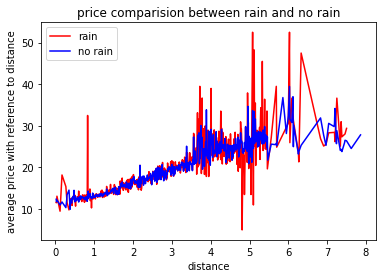

In [175]:
rain = cab_drives_weather[cab_drives_weather['rain'] != 0]
rain = rain.groupby('distance')['price']
no_rain = cab_drives_weather[cab_drives_weather['rain'] == 0]
no_rain = no_rain.groupby('distance')['price']

plt.title('price comparision between rain and no rain')
plt.xlabel('distance')
plt.ylabel('average price with reference to distance')
plt.plot(rain.groups.keys(), rain.mean(), label='rain', c='r')
plt.plot(no_rain.groups.keys(), no_rain.mean(), label='no rain', c='b')
plt.legend()
plt.show()

In [213]:
print("总体而言，下雨的话价格波动更大一下，尤其当距离非常长的的时候价格波动更为显著。")

总体而言，下雨的话价格波动更大一下，尤其当距离非常长的的时候价格波动更为显著。


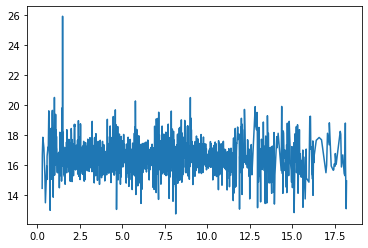

In [214]:
wind= cab_drives_weather.groupby('wind')['price']
plt.plot(wind.groups.keys(), wind.mean())
plt.show()

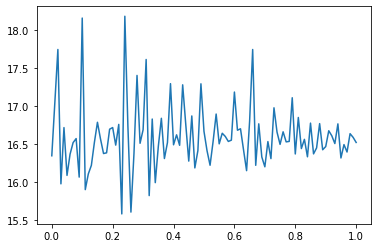

In [216]:
clouds= cab_drives_weather.groupby('clouds')['price']
plt.plot(clouds.groups.keys(), clouds.mean())
plt.show()

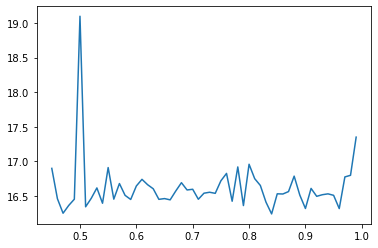

In [217]:
humidity= cab_drives_weather.groupby('humidity')['price']
plt.plot(humidity.groups.keys(), humidity.mean())
plt.show()

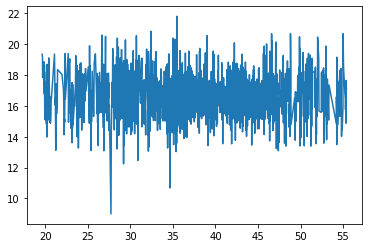

In [218]:
temp= cab_drives_weather.groupby('temp')['price']
plt.plot(temp.groups.keys(), temp.mean())
plt.show()

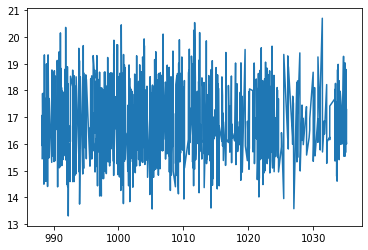

In [219]:
pressure= cab_drives_weather.groupby('pressure')['price']
plt.plot(pressure.groups.keys(), pressure.mean())
plt.show()

In [220]:
print("剩下几项影响气候的因素除了云似乎在其密度较低的时候价格波动较大之外，剩下对价格的影响没有明显的变化。")

剩下几项影响气候的因素除了云似乎在其密度较低的时候价格波动较大之外，剩下对价格的影响没有明显的变化。
